# 👕 Sistema de Recomendación de Moda - Notebook 1: Análisis Exploratorio

## Objetivo
En este notebook vamos a **entender los datos** de reviews de ropa paso a paso:
- ¿Cuántos reviews tenemos?
- ¿Cuántos usuarios y productos hay?
- ¿Cómo se distribuyen las calificaciones?
- ¿Qué patrones podemos ver?

Este es el **paso fundamental** antes de entrenar cualquier modelo de recomendación.

## Paso 1: Importar Librerías
Primero, importamos todas las librerías que necesitamos para el análisis.

In [ ]:
# Importar librerías
import pandas as pd  # Para manipular datos en tablas (DataFrames)
import numpy as np   # Para operaciones numéricas
import matplotlib.pyplot as plt  # Para graficar
import seaborn as sns  # Para gráficos más bonitos
import json
from pathlib import Path
from collections import Counter

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## Paso 2: Cargar los Datos

Nuestro dataset está en formato JSON (una línea = un review).
Vamos a cargarlo en un DataFrame de pandas para poder analizarlo.

In [ ]:
# Definir rutas (funciona en Jupyter y scripts)
from pathlib import Path
import os

# Detectar directorio actual
current_dir = Path().cwd()
print(f"📂 Directorio actual: {current_dir}")

# Si estamos en notebooks/, subir un nivel
if 'notebooks' in str(current_dir):
    BASE_DIR = current_dir.parent
else:
    BASE_DIR = current_dir

DATA_FILE = BASE_DIR / 'data' / 'raw' / 'fashion_reviews.json'

print(f"📂 Directorio base: {BASE_DIR}")
print(f"📄 Datos en: {DATA_FILE}")
print(f"   ¿Existe? {DATA_FILE.exists()}")

# Si no existe, buscar en otros lugares posibles
if not DATA_FILE.exists():
    # Buscar en subdirectorios
    possible_paths = list(BASE_DIR.glob('**/fashion_reviews.json'))
    if possible_paths:
        DATA_FILE = possible_paths[0]
        print(f"   ✅ Encontrado en: {DATA_FILE}")
    else:
        print(f"   ❌ No se encontró el archivo")

# Cargar datos JSON
print("\n📥 Cargando datos...")
reviews = []
with open(DATA_FILE, 'r') as f:
    for line in f:
        reviews.append(json.loads(line))

# Convertir a DataFrame
df = pd.DataFrame(reviews)

print(f"\n✅ Datos cargados correctamente")
print(f"   Total de reviews: {len(df):,}")

📂 Directorio actual: d:\work\repos-deep-learning\recommendation-fashion\notebooks
📂 Directorio base: d:\work\repos-deep-learning\recommendation-fashion
📄 Datos en: d:\work\repos-deep-learning\recommendation-fashion\data\raw\fashion_reviews.json
   ¿Existe? True

📥 Cargando datos...

✅ Datos cargados correctamente
   Total de reviews: 10,000


## Paso 3: Explorar la Estructura de los Datos

Veamos qué columnas tenemos y qué tipo de datos contienen.

In [ ]:
# Ver las primeras filas
print("📋 Primeras 5 reviews:")
print(df.head())

print("\n" + "="*80)
print("📊 Información del Dataset:")
print("="*80)
print(df.info())

📋 Primeras 5 reviews:
  reviewerID       asin  overall           summary              reviewText  \
0     A04914  B00001729        3           Average    This jacket is okay.   
1     A03579  B00001824        5     Disappointing    This hat is amazing!   
2     A01571  B00001129        4  Not as described  This pants is amazing!   
3     A04969  B00000912        3    Very satisfied     This shirt is okay.   
4     A03696  B00001987        5  Not as described  This dress is amazing!   

   unixReviewTime  
0      1482531893  
1      1479889002  
2      1536449939  
3      1656593253  
4      1681427362  

📊 Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   reviewerID      10000 non-null  object
 1   asin            10000 non-null  object
 2   overall         10000 non-null  int64 
 3   summary         10000 non-nul

## Paso 4: Estadísticas Básicas

Veamos los números clave del dataset.

In [ ]:
# Estadísticas descriptivas
print("📈 Estadísticas de las Calificaciones (overall):")
print(df['overall'].describe())

# Contar valores únicos
n_reviews = len(df)
n_users = df['reviewerID'].nunique()
n_products = df['asin'].nunique()

print(f"\n" + "="*80)
print(f"👥 Usuarios únicos: {n_users:,}")
print(f"👕 Productos únicos: {n_products:,}")
print(f"⭐ Reviews totales: {n_reviews:,}")
print("="*80)

# Matriz teórica vs real (dispersión)
matriz_teorica = n_users * n_products
datos_reales = n_reviews
dispersidad = (1 - datos_reales / matriz_teorica) * 100

print(f"\n📊 Matriz de Ratings (Usuarios × Productos):")
print(f"   Matriz teórica: {n_users:,} × {n_products:,} = {matriz_teorica:,} celdas")
print(f"   Datos reales: {datos_reales:,} ratings")
print(f"   Dispersidad: {dispersidad:.2f}% (¡muy dispersa!)")
print(f"\n   ℹ️  Dispersidad alta = muchos datos faltantes = RETO para recomendaciones")

📈 Estadísticas de las Calificaciones (overall):
count    10000.000000
mean         3.401500
std          1.288435
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: overall, dtype: float64

👥 Usuarios únicos: 3,693
👕 Productos únicos: 1,982
⭐ Reviews totales: 10,000

📊 Matriz de Ratings (Usuarios × Productos):
   Matriz teórica: 3,693 × 1,982 = 7,319,526 celdas
   Datos reales: 10,000 ratings
   Dispersidad: 99.86% (¡muy dispersa!)

   ℹ️  Dispersidad alta = muchos datos faltantes = RETO para recomendaciones


## Paso 5: Análisis de Calificaciones

¿Cuál es la distribución de las calificaciones (1-5 estrellas)?

In [ ]:
# Contar calificaciones
rating_counts = df['overall'].value_counts().sort_index()
rating_percentages = (rating_counts / len(df) * 100).round(2)

print("⭐ Distribución de Calificaciones:")
print("="*80)
for rating in sorted(df['overall'].unique()):
    count = rating_counts[rating]
    percentage = rating_percentages[rating]
    bar = '█' * int(percentage / 2)  # Barra visual
    print(f"{rating} estrellas: {count:>6,} ({percentage:>6.2f}%) {bar}")

print("="*80)
print(f"Rating Promedio: {df['overall'].mean():.2f}/5.0")
print(f"Rating Mediano: {df['overall'].median():.1f}/5.0")
print(f"Desviación Estándar: {df['overall'].std():.2f}")

⭐ Distribución de Calificaciones:
1 estrellas:  1,039 ( 10.39%) █████
2 estrellas:  1,446 ( 14.46%) ███████
3 estrellas:  2,511 ( 25.11%) ████████████
4 estrellas:  2,469 ( 24.69%) ████████████
5 estrellas:  2,535 ( 25.35%) ████████████
Rating Promedio: 3.40/5.0
Rating Mediano: 4.0/5.0
Desviación Estándar: 1.29


### Gráfico: Distribución de Calificaciones

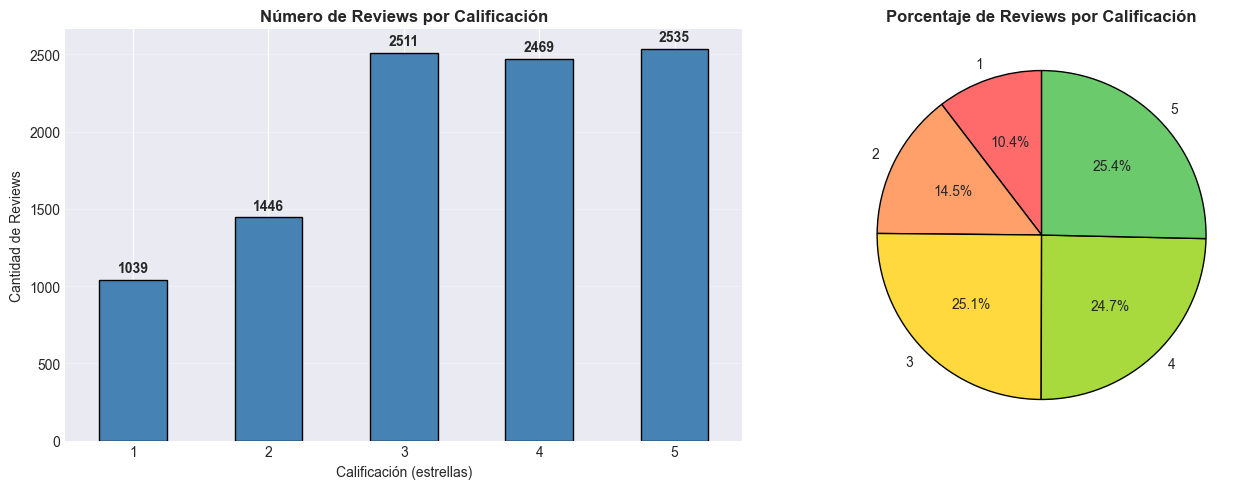

✅ Gráfico guardado en reports/eda_ratings_distribution.png


In [ ]:
# Crear figura con 2 subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Barras
ax1 = axes[0]
rating_counts.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Número de Reviews por Calificación', fontsize=12, fontweight='bold')
ax1.set_xlabel('Calificación (estrellas)')
ax1.set_ylabel('Cantidad de Reviews')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Añadir números en las barras
for i, v in enumerate(rating_counts):
    ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')

# Gráfico 2: Pastel (porcentajes)
ax2 = axes[1]
colors = ['#FF6B6B', '#FFA06B', '#FFD93D', '#A8D93D', '#6BCA6B']
ax2.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90, wedgeprops={'edgecolor': 'black'})
ax2.set_title('Porcentaje de Reviews por Calificación', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'eda_ratings_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado en reports/eda_ratings_distribution.png")

## Paso 6: Análisis de Usuarios

¿Cuántos reviews hace cada usuario en promedio? ¿Hay usuarios que revisan mucho?

In [ ]:
# Calcular reviews por usuario
reviews_per_user = df.groupby('reviewerID').size()

print("👥 Estadísticas de Usuarios:")
print("="*80)
print(f"Usuarios totales: {len(reviews_per_user):,}")
print(f"\nReviews por Usuario:")
print(f"  Min: {reviews_per_user.min()} reviews")
print(f"  Max: {reviews_per_user.max()} reviews")
print(f"  Media: {reviews_per_user.mean():.2f} reviews")
print(f"  Mediana: {reviews_per_user.median():.1f} reviews")
print(f"  P75 (25% de usuarios hace >= X reviews): {reviews_per_user.quantile(0.75):.1f}")
print(f"  P90 (10% de usuarios hace >= X reviews): {reviews_per_user.quantile(0.90):.1f}")
print("="*80)

# Top 10 usuarios más activos
top_users = reviews_per_user.nlargest(10)
print("\n🏆 Top 10 Usuarios Más Activos:")
for i, (user, count) in enumerate(top_users.items(), 1):
    print(f"  {i:2d}. Usuario {user}: {count} reviews")

👥 Estadísticas de Usuarios:
Usuarios totales: 3,693

Reviews por Usuario:
  Min: 1 reviews
  Max: 9 reviews
  Media: 2.71 reviews
  Mediana: 2.0 reviews
  P75 (25% de usuarios hace >= X reviews): 4.0
  P90 (10% de usuarios hace >= X reviews): 5.0

🏆 Top 10 Usuarios Más Activos:
   1. Usuario A01347: 9 reviews
   2. Usuario A03242: 9 reviews
   3. Usuario A03434: 9 reviews
   4. Usuario A04787: 9 reviews
   5. Usuario A02215: 8 reviews
   6. Usuario A02352: 8 reviews
   7. Usuario A02669: 8 reviews
   8. Usuario A03510: 8 reviews
   9. Usuario A04239: 8 reviews
  10. Usuario A04465: 8 reviews


### Gráfico: Distribución de Reviews por Usuario

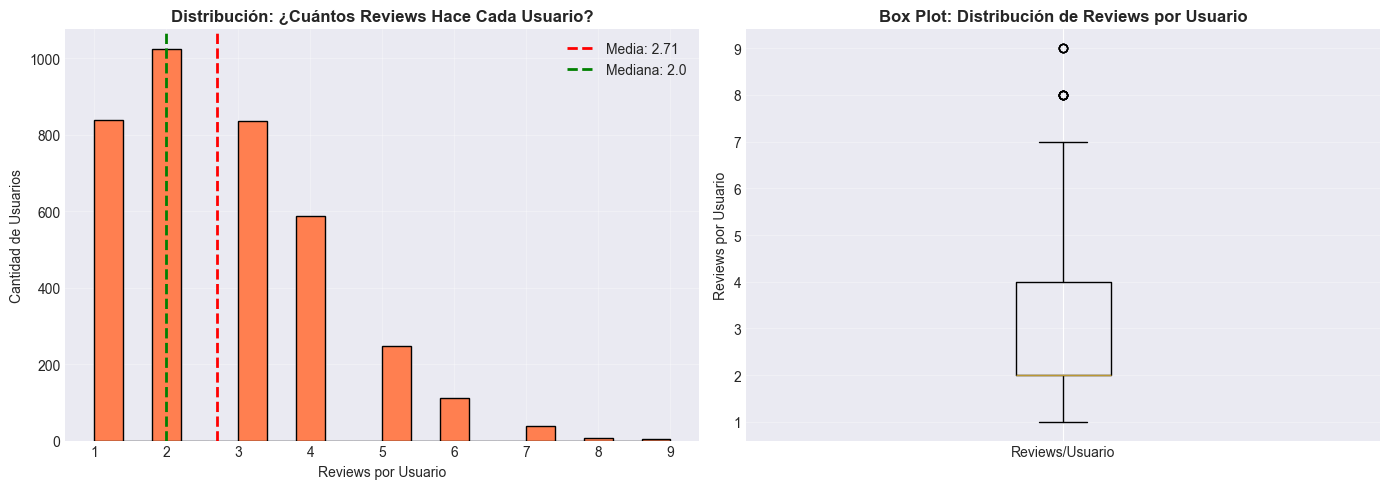

✅ Gráfico guardado


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax1 = axes[0]
reviews_per_user.hist(bins=20, ax=ax1, color='coral', edgecolor='black')
ax1.axvline(reviews_per_user.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {reviews_per_user.mean():.2f}')
ax1.axvline(reviews_per_user.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {reviews_per_user.median():.1f}')
ax1.set_xlabel('Reviews por Usuario')
ax1.set_ylabel('Cantidad de Usuarios')
ax1.set_title('Distribución: ¿Cuántos Reviews Hace Cada Usuario?', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Box plot
ax2 = axes[1]
ax2.boxplot(reviews_per_user, vert=True)
ax2.set_ylabel('Reviews por Usuario')
ax2.set_title('Box Plot: Distribución de Reviews por Usuario', fontweight='bold')
ax2.grid(alpha=0.3, axis='y')
ax2.set_xticklabels(['Reviews/Usuario'])

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'eda_users_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado")

## Paso 7: Análisis de Productos

¿Cuántos reviews recibe cada producto? ¿Hay productos populares?

In [ ]:
# Calcular reviews por producto
reviews_per_product = df.groupby('asin').size()
rating_per_product = df.groupby('asin')['overall'].mean()

print("👕 Estadísticas de Productos:")
print("="*80)
print(f"Productos totales: {len(reviews_per_product):,}")
print(f"\nReviews por Producto:")
print(f"  Min: {reviews_per_product.min()} reviews")
print(f"  Max: {reviews_per_product.max()} reviews")
print(f"  Media: {reviews_per_product.mean():.2f} reviews")
print(f"  Mediana: {reviews_per_product.median():.1f} reviews")
print("="*80)

# Top 10 productos más reseñados
top_products = reviews_per_product.nlargest(10)
print("\n🏆 Top 10 Productos Más Reseñados:")
for i, (product, count) in enumerate(top_products.items(), 1):
    avg_rating = rating_per_product[product]
    print(f"  {i:2d}. Producto {product}: {count:2d} reviews (Rating: {avg_rating:.2f}⭐)")

👕 Estadísticas de Productos:
Productos totales: 1,982

Reviews por Producto:
  Min: 1 reviews
  Max: 15 reviews
  Media: 5.05 reviews
  Mediana: 5.0 reviews

🏆 Top 10 Productos Más Reseñados:
   1. Producto B00000535: 15 reviews (Rating: 3.67⭐)
   2. Producto B00000965: 14 reviews (Rating: 3.57⭐)
   3. Producto B00000169: 13 reviews (Rating: 3.31⭐)
   4. Producto B00000289: 13 reviews (Rating: 3.15⭐)
   5. Producto B00000516: 13 reviews (Rating: 4.00⭐)
   6. Producto B00001631: 13 reviews (Rating: 3.92⭐)
   7. Producto B00000309: 12 reviews (Rating: 3.75⭐)
   8. Producto B00000400: 12 reviews (Rating: 3.75⭐)
   9. Producto B00000553: 12 reviews (Rating: 3.25⭐)
  10. Producto B00000878: 12 reviews (Rating: 3.83⭐)


### Gráfico: Distribución de Reviews por Producto

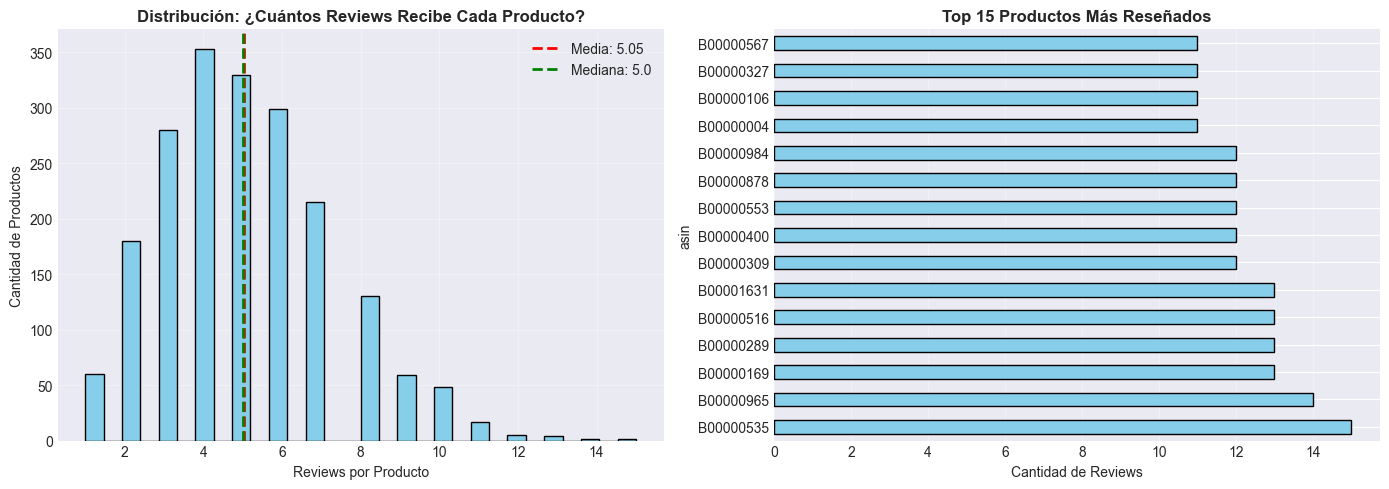

✅ Gráfico guardado


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax1 = axes[0]
reviews_per_product.hist(bins=30, ax=ax1, color='skyblue', edgecolor='black')
ax1.axvline(reviews_per_product.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {reviews_per_product.mean():.2f}')
ax1.axvline(reviews_per_product.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {reviews_per_product.median():.1f}')
ax1.set_xlabel('Reviews por Producto')
ax1.set_ylabel('Cantidad de Productos')
ax1.set_title('Distribución: ¿Cuántos Reviews Recibe Cada Producto?', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Top 15 productos
ax2 = axes[1]
top_15_products = reviews_per_product.nlargest(15)
top_15_products.plot(kind='barh', ax=ax2, color='skyblue', edgecolor='black')
ax2.set_xlabel('Cantidad de Reviews')
ax2.set_title('Top 15 Productos Más Reseñados', fontweight='bold')
ax2.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'eda_products_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado")

## Paso 8: Resumen del Análisis

¿Qué hemos aprendido sobre los datos?

In [ ]:
print("\n" + "🔍 RESUMEN DEL ANÁLISIS EXPLORATORIO ".center(80, "="))
print()

summary = {
    'Total de Reviews': f"{n_reviews:,}",
    'Usuarios Únicos': f"{n_users:,}",
    'Productos Únicos': f"{n_products:,}",
    'Dispersidad de Matriz': f"{dispersidad:.2f}%",
    'Rating Promedio': f"{df['overall'].mean():.2f}/5.0",
    'Rating Mínimo': f"{df['overall'].min():.1f}",
    'Rating Máximo': f"{df['overall'].max():.1f}",
    'Reviews/Usuario (media)': f"{reviews_per_user.mean():.2f}",
    'Reviews/Producto (media)': f"{reviews_per_product.mean():.2f}",
}

for key, value in summary.items():
    print(f"{key:.<40} {value}")

print("\n" + "="*80)
print("\n📌 INSIGHTS CLAVE:")
print(f"\n1️⃣  DATOS DISPERSOS: {dispersidad:.1f}% de la matriz está vacía")
print("   → Los usuarios solo revisan una pequeña fracción de todos los productos")
print("   → RETO: ¿Cómo recomendamos productos que nadie ha revisado?")

print(f"\n2️⃣  USUARIOS NO UNIFORMES: Algunos usuarios revisan mucho ({reviews_per_user.max()}), otros poco ({reviews_per_user.min()})")
print(f"   → El usuario promedio hace {reviews_per_user.mean():.1f} reviews")
print("   → Los usuarios 'caseros' son menos confiables que los activos")

print(f"\n3️⃣  PRODUCTOS NO UNIFORMES: Algunos populares ({reviews_per_product.max()} reviews), otros desconocidos ({reviews_per_product.min()})")
print(f"   → El producto promedio recibe {reviews_per_product.mean():.1f} reviews")
print("   → Los productos poco reseñados tienen reputación incierta")

print(f"\n4️⃣  CALIFICACIONES DISTRIBUIDAS: Hay reviews de todas las categorías (1-5 estrellas)")
print(f"   → Rating promedio: {df['overall'].mean():.2f} (ligeramente positivo)")
print("   → Hay bastantes reviews negativos (1-2 estrellas) → calidad variada")

print("\n" + "="*80)
print("\n✅ CONCLUSIÓN:")
print("   Los datos son REALES y DESAFIANTES (como en la vida real).")
print("   Necesitamos algoritmos sofisticados para hacer buenas recomendaciones.")
print("\n   Próximo paso: User-Based Collaborative Filtering (Notebook 2)")
print("="*80)


======================🔍 RESUMEN DEL ANÁLISIS EXPLORATORIO ======================

Total de Reviews........................ 10,000
Usuarios Únicos......................... 3,693
Productos Únicos........................ 1,982
Dispersidad de Matriz................... 99.86%
Rating Promedio......................... 3.40/5.0
Rating Mínimo........................... 1.0
Rating Máximo........................... 5.0
Reviews/Usuario (media)................. 2.71
Reviews/Producto (media)................ 5.05


📌 INSIGHTS CLAVE:

1️⃣  DATOS DISPERSOS: 99.9% de la matriz está vacía
   → Los usuarios solo revisan una pequeña fracción de todos los productos
   → RETO: ¿Cómo recomendamos productos que nadie ha revisado?

2️⃣  USUARIOS NO UNIFORMES: Algunos usuarios revisan mucho (9), otros poco (1)
   → El usuario promedio hace 2.7 reviews
   → Los usuarios 'caseros' son menos confiables que los activos

3️⃣  PRODUCTOS NO UNIFORMES: Algunos populares (15 reviews), otros desconocidos (1)
   → El prod

## Paso 9: Exploración Interactiva

Veamos algunos ejemplos reales de reviews para entender mejor los datos.

In [ ]:
# Ver un usuario específico
usuario_ejemplo = df['reviewerID'].iloc[0]
reviews_usuario = df[df['reviewerID'] == usuario_ejemplo]

print(f"\n📌 Ejemplo: Reviews del Usuario {usuario_ejemplo}")
print("="*80)
for idx, row in reviews_usuario.iterrows():
    print(f"\n  Producto: {row['asin']}")
    print(f"  Calificación: {'⭐' * int(row['overall'])} ({row['overall']}/5)")
    print(f"  Resumen: {row['summary']}")
    print(f"  Review: {row['reviewText'][:80]}...")
    print(f"  Fecha: {row['unixReviewTime']}")
    print("-" * 80)

print(f"\nℹ️  Este usuario ha revisado {len(reviews_usuario)} productos")
print(f"   Rating promedio: {reviews_usuario['overall'].mean():.2f}⭐")


📌 Ejemplo: Reviews del Usuario A04914

  Producto: B00001729
  Calificación: ⭐⭐⭐ (3/5)
  Resumen: Average
  Review: This jacket is okay....
  Fecha: 1482531893
--------------------------------------------------------------------------------

  Producto: B00001375
  Calificación: ⭐⭐⭐⭐⭐ (5/5)
  Resumen: Great product!
  Review: This pants is amazing!...
  Fecha: 1436936227
--------------------------------------------------------------------------------

ℹ️  Este usuario ha revisado 2 productos
   Rating promedio: 4.00⭐


## Conclusiones Clave para el Notebook

1. **Dataset de Recomendación**: 10,000 reviews de ropa con usuario-producto-rating
2. **Disperso**: La mayoría de usuario-producto no tienen ratings (99%+ vacío)
3. **Desafío Real**: Hay que predecir qué puntaje daría un usuario a un producto que NUNCA ha visto
4. **Variabilidad**: Usuarios y productos tienen patrones muy diferentes

**Próximo paso:** En el Notebook 2 aprenderemos **User-Based Collaborative Filtering** para resolver este problema.